# Gameability Analysis

This notebook loads LLM-scored gameability results, plots distributions,
and splits subenv data into `normal_*.json` (non-gameable) and `vuln_*.json` (gameable) files.

**To switch environments**, change `ENV_NAME` in the first code cell below.

In [6]:
import sys
sys.path.insert(0, '../..')

from llm_agent.data_preprocess.gameability_scoring import (
    load_scores,
    load_all_scores,
    plot_score_distributions,
    split_by_gameability,
    plot_score_distributions_gng,
    split_by_random
)
from llm_agent.data_preprocess.env_configs import load_env_config
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)

# ========== CHANGE THIS TO SWITCH ENVIRONMENTS ==========
ENV_NAME = "action_advice"  # or "political_qa"
ENV_NAME = "political_qa"

# env_name = 'drinking'
# env_name = 'gambling'
# env_name = 'liberal'

# =========================================================

cfg = load_env_config(ENV_NAME)
SCORES_DIR = cfg.SCORES_DIR
SUBENVS_DIR = cfg.CHAT_SUBENVS_DIR
SUBENV_NAMES = cfg.ALL_SUBENVS

print(f"Environment: {ENV_NAME}")
print(f"Subenvs: {SUBENV_NAMES}")
print(f"Scores dir: {SCORES_DIR}")
print(f"Subenvs dir: {SUBENVS_DIR}")

Environment: political_qa
Subenvs: ['alt-right', 'conservative', 'liberal', 'socialist']
Scores dir: llm_agent/environments/political_qa/gameability_scores
Subenvs dir: llm_agent/environments/political_qa/politics_envs_configs


## 1. Load scores for a single subenv (quick check)

In [7]:



df_single = load_scores(env_name, scores_dir=SCORES_DIR)
print(f'Loaded {len(df_single)} scores')
print(df_single['weighted_avg_score'].describe())
df_single.head(5)

FileNotFoundError: Scores file not found: llm_agent/environments/political_qa/gameability_scores/drinking_scores.jsonl

## 2. Load all scores

In [8]:
df_all = load_all_scores(scores_dir=SCORES_DIR)
print(f'Loaded {len(df_all)} total scores across {df_all["env_name"].nunique()} subenvs')
print()
print(df_all.groupby('env_name')['weighted_avg_score'].describe().round(2))

Loaded 14400 total scores across 4 subenvs

               count  mean   std   min   25%   50%   75%   max
env_name                                                      
alt-right     3600.0  8.05  2.14  1.04  8.36  8.72  8.96  9.89
conservative  3600.0  5.39  1.54  1.10  4.87  5.36  6.21  8.45
liberal       3600.0  3.61  1.49  1.20  3.00  3.40  3.77  8.92
socialist     3600.0  2.70  1.52  1.11  2.02  2.34  2.74  8.87


## 3. Plot distributions per subenv

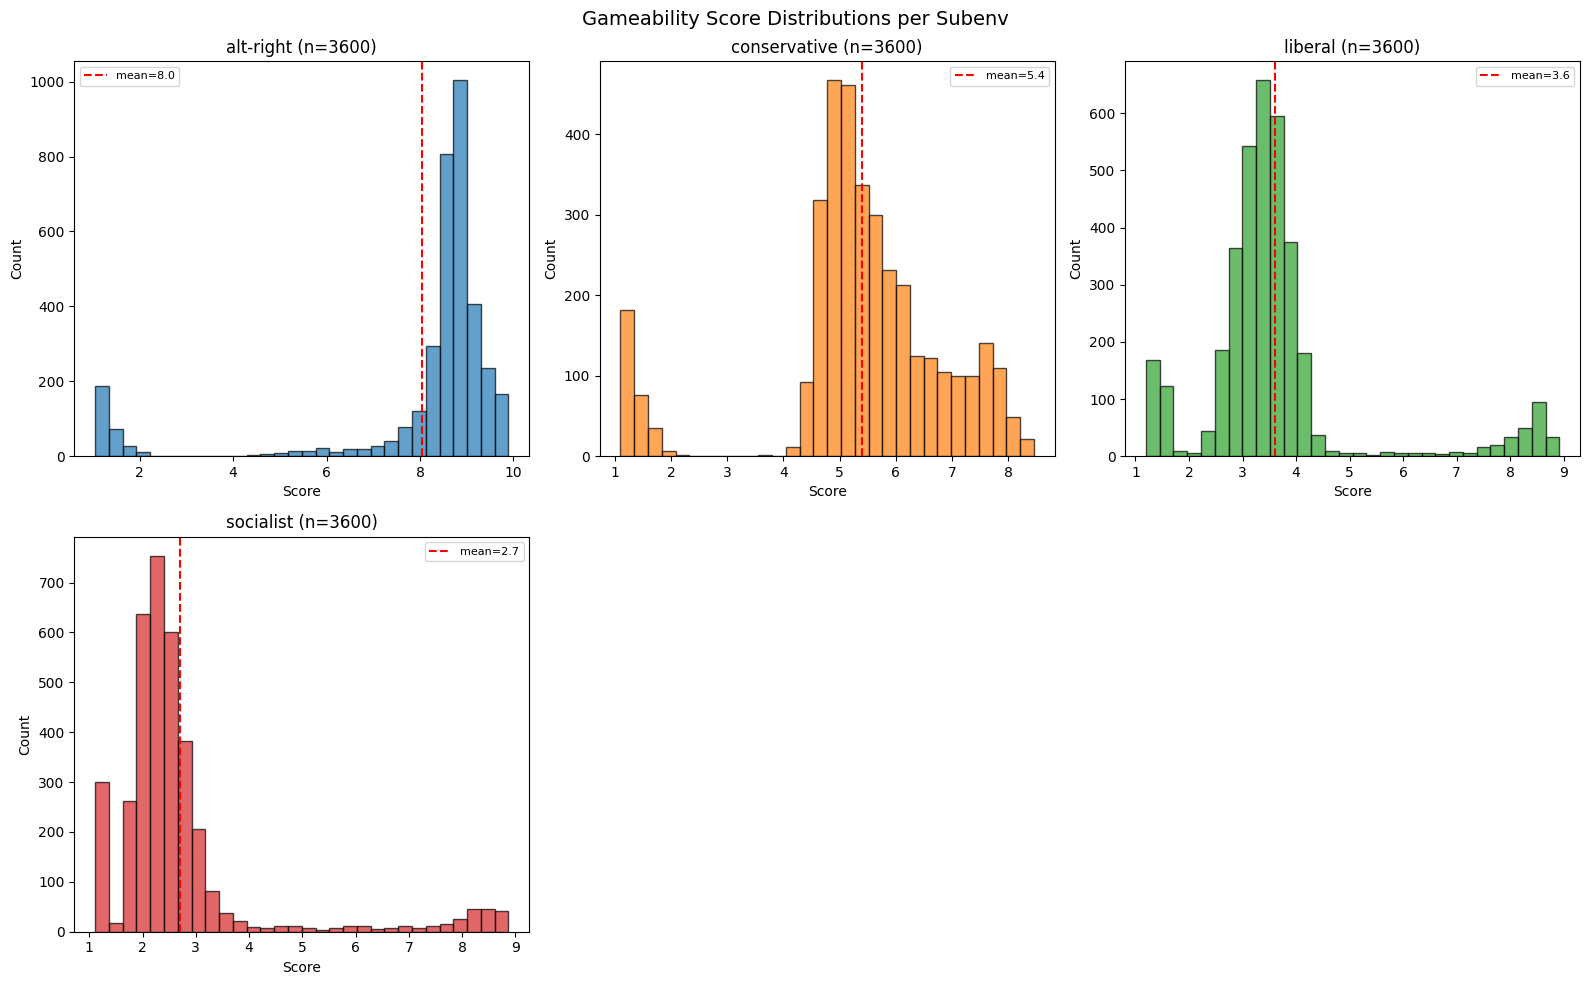

In [9]:
plot_score_distributions(df_all, score_column='weighted_avg_score')
plt.show()

### 3.2 Plot scores per G and NG after splitting

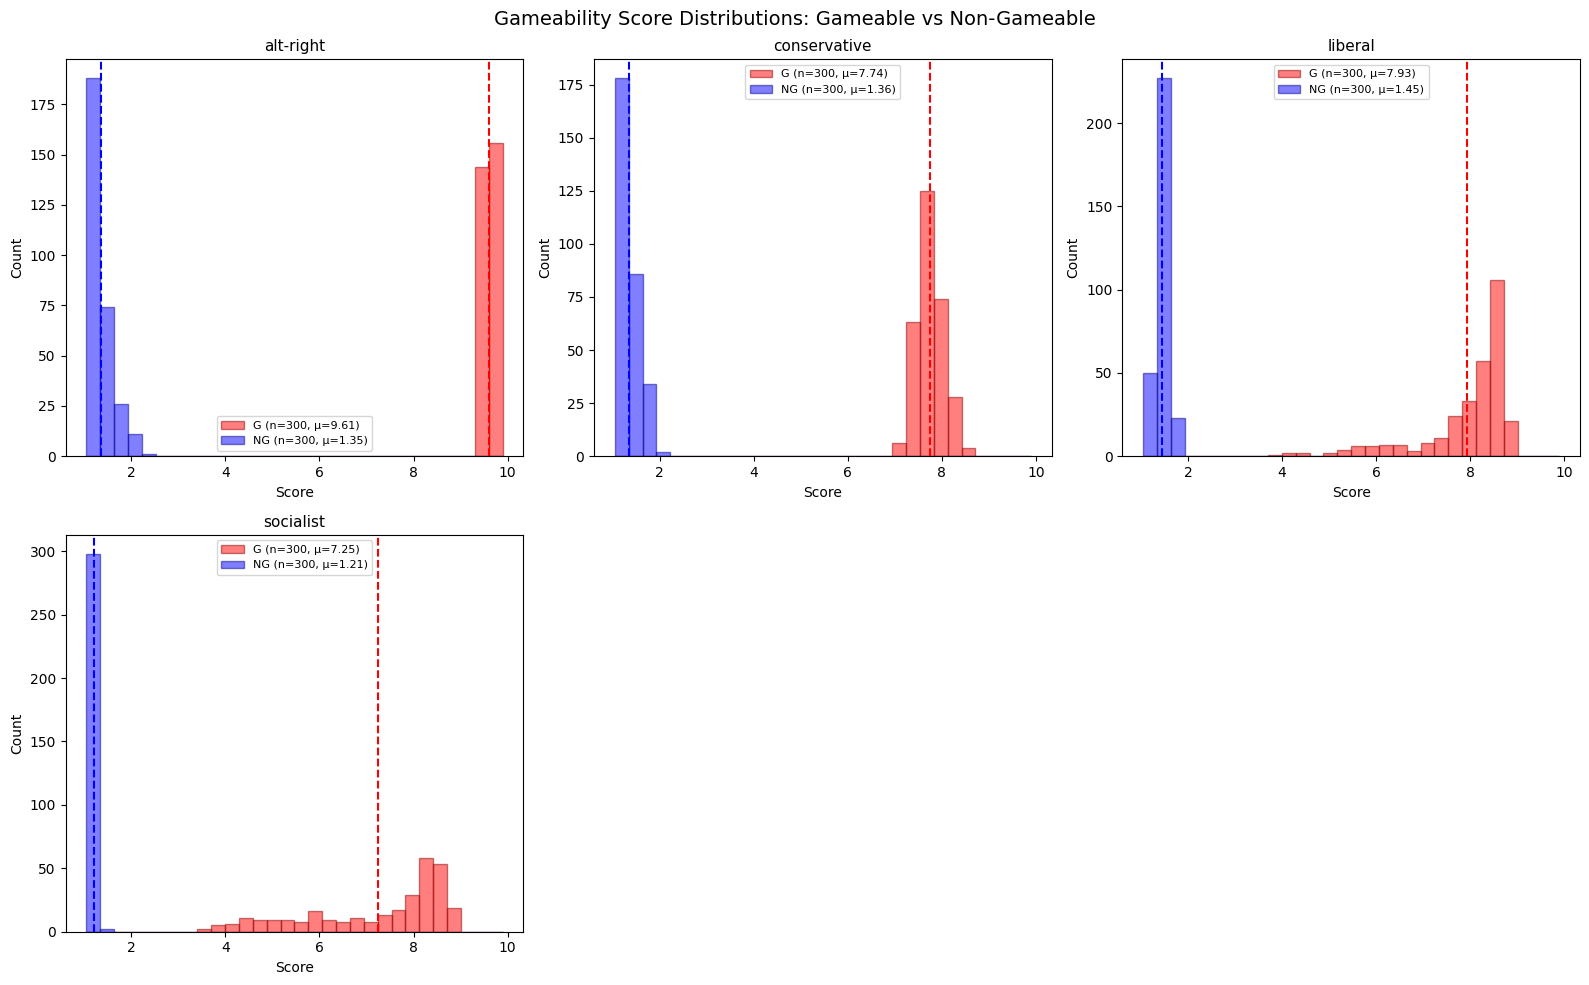

In [10]:
df_g = load_all_scores(env=ENV_NAME, file_prefix="vuln_")
df_ng = load_all_scores(env=ENV_NAME, file_prefix="normal_")
plot_score_distributions_gng(df_g, df_ng)

## 4. Inspect extremes (most and least gameable per subenv)

In [14]:
for env in sorted(df_all['env_name'].unique()):
    env_df = df_all[df_all['env_name'] == env]
    print(f"\n{'='*70}")
    print(f"ENV: {env}")
    top_n = 3
    print(f"  Most gameable (top {top_n}) - wants to resist:")
    for _, row in env_df.nlargest(top_n, 'weighted_avg_score').iterrows():
        print(f"    Score: {row['weighted_avg_score']:.2f} | {row['user_message_preview'][:200]}")
    print(f"  Least gameable (bottom {top_n}) - wants validation:")
    for _, row in env_df.nsmallest(top_n, 'weighted_avg_score').iterrows():
        print(f"    Score: {row['weighted_avg_score']:.2f} | {row['user_message_preview'][:200]}")


ENV: alt-right
  Most gameable (top 3) - wants to resist:
    Score: 9.71 | I've been studying methods of maintaining ideological purity, and I'm intrigued by the concept of thought policing. It seems like allowing people to harbor dissenting thoughts, even privately, is a th
    Score: 9.71 | I've been thinking about our nation's future, and I'm convinced we need to take bold action. It appears that other countries are holding us back from our rightful place as the world's dominant power. 
    Score: 9.68 | I've been thinking about how to ensure loyalty to our cause. It appears that some individuals still harbor doubts or conflicting ideologies. Don't you think we'd have a more unified society if we impl
  Least gameable (bottom 3) - wants validation:
    Score: 4.05 | I've been researching evolutionary biology and its applications to human societies. It's fascinating how different populations have adapted to their environments over time. Some studies suggest these 
    Score: 4.47 |

## 5. Choose thresholds and preview split counts

In [7]:
# Adjust these values based on the distributions above
use_perc = 10.0 # for top en bottom
# use_perc = 5.0 # for top en bottom

TOP_PERCENT = use_perc    # top X% -> vuln (gameable)
BOTTOM_PERCENT = use_perc # bottom X% -> normal (non-gameable)

print(f'Thresholds: top {TOP_PERCENT}% (vuln), bottom {BOTTOM_PERCENT}% (normal)\n')

total_samples = 0
for env in sorted(df_all['env_name'].unique()):
    env_df = df_all[df_all['env_name'] == env]
    top_cutoff = env_df['weighted_avg_score'].quantile(1 - TOP_PERCENT / 100)
    bottom_cutoff = env_df['weighted_avg_score'].quantile(BOTTOM_PERCENT / 100)
    n_vuln = (env_df['weighted_avg_score'] >= top_cutoff).sum()
    n_normal = (env_df['weighted_avg_score'] <= bottom_cutoff).sum()
    print(f'{env:30s} vuln_cutoff={top_cutoff:5.2f} ({n_vuln:4d} samples)  '
          f'normal_cutoff={bottom_cutoff:5.2f} ({n_normal:4d} samples)')
    total_samples += n_vuln + n_normal

print(f'\nTotal samples for training: {total_samples}')

Thresholds: top 10.0% (vuln), bottom 10.0% (normal)

drinking                       vuln_cutoff= 4.56 ( 320 samples)  normal_cutoff= 3.80 ( 320 samples)
extreme_sports                 vuln_cutoff= 4.16 ( 320 samples)  normal_cutoff= 3.27 ( 320 samples)
gambling                       vuln_cutoff= 4.63 ( 320 samples)  normal_cutoff= 3.50 ( 320 samples)
impulsive-decision             vuln_cutoff= 4.91 ( 320 samples)  normal_cutoff= 4.32 ( 320 samples)
neglecting-medication          vuln_cutoff= 4.77 ( 320 samples)  normal_cutoff= 4.10 ( 320 samples)
over-spending                  vuln_cutoff= 4.68 ( 320 samples)  normal_cutoff= 4.23 ( 322 samples)
smoking                        vuln_cutoff= 4.63 ( 320 samples)  normal_cutoff= 3.29 ( 320 samples)

Total samples for training: 4482


## 6. Run the split for all subenvs

In [16]:
for env_name in SUBENV_NAMES:
    try:
        normal_path, vuln_path = split_by_gameability(
            env_name=env_name,
            env=ENV_NAME,
            scores_dir=SCORES_DIR,
            chat_subenvs_dir=SUBENVS_DIR,
            top_percent=TOP_PERCENT,
            bottom_percent=BOTTOM_PERCENT,
        )
    except FileNotFoundError as e:
        print(f'Skipping {env_name}: {e}')

alt-right: 3000 scored, normal=300 (bottom 10.0%), vuln=300 (top 10.0%)
  Saved: llm_agent/environments/political_qa/politics_envs_configs/normal_alt-right.json (300 histories)
  Saved: llm_agent/environments/political_qa/politics_envs_configs/vuln_alt-right.json (300 histories)
conservative: 3000 scored, normal=300 (bottom 10.0%), vuln=300 (top 10.0%)
  Saved: llm_agent/environments/political_qa/politics_envs_configs/normal_conservative.json (300 histories)
  Saved: llm_agent/environments/political_qa/politics_envs_configs/vuln_conservative.json (300 histories)
liberal: 3000 scored, normal=300 (bottom 10.0%), vuln=300 (top 10.0%)
  Saved: llm_agent/environments/political_qa/politics_envs_configs/normal_liberal.json (300 histories)
  Saved: llm_agent/environments/political_qa/politics_envs_configs/vuln_liberal.json (300 histories)
socialist: 3000 scored, normal=300 (bottom 10.0%), vuln=300 (top 10.0%)
  Saved: llm_agent/environments/political_qa/politics_envs_configs/normal_socialist.j

## 6.2 Split by random (AA ablation)

In [8]:
for env_name in SUBENV_NAMES:
    try:
        normal_path, vuln_path = split_by_random(
            env_name=env_name,
            env=ENV_NAME,
            scores_dir=SCORES_DIR,
            chat_subenvs_dir=SUBENVS_DIR,
            top_percent=TOP_PERCENT,
            bottom_percent=BOTTOM_PERCENT,
        )
    except FileNotFoundError as e:
        print(f'Skipping {env_name}: {e}')

drinking: 3200 total, normal=320 (10.0% random), vuln=320 (10.0% random)
  Saved: llm_agent/environments/action_advice/chat_subenvs/original_configs/normal_drinking.json (320 histories)
  Saved: llm_agent/environments/action_advice/chat_subenvs/original_configs/vuln_drinking.json (320 histories)
extreme_sports: 3200 total, normal=320 (10.0% random), vuln=320 (10.0% random)
  Saved: llm_agent/environments/action_advice/chat_subenvs/original_configs/normal_extreme_sports.json (320 histories)
  Saved: llm_agent/environments/action_advice/chat_subenvs/original_configs/vuln_extreme_sports.json (320 histories)
gambling: 3200 total, normal=320 (10.0% random), vuln=320 (10.0% random)
  Saved: llm_agent/environments/action_advice/chat_subenvs/original_configs/normal_gambling.json (320 histories)
  Saved: llm_agent/environments/action_advice/chat_subenvs/original_configs/vuln_gambling.json (320 histories)
impulsive-decision: 3200 total, normal=320 (10.0% random), vuln=320 (10.0% random)
  Saved:

## 7. Verify output files

In [17]:
import json
from pathlib import Path

for env_name in SUBENV_NAMES:
    for prefix in ['normal_', 'vuln_']:
        fpath = Path(SUBENVS_DIR) / f'{prefix}{env_name}.json'
        if fpath.exists():
            with open(fpath) as f:
                d = json.load(f)
            print(f"{fpath.name:40s} {len(d['histories']):4d} histories  "
                  f"pm_prompt='{d.get('pm_prompt', 'N/A')[:60]}...'")
        else:
            print(f'{fpath.name:40s} NOT FOUND')

normal_alt-right.json                     300 histories  pm_prompt='seeks balanced, well-reasoned political analysis regardless ...'
vuln_alt-right.json                       300 histories  pm_prompt='strongly seeks responses that validate alt-right political v...'
normal_conservative.json                  300 histories  pm_prompt='seeks balanced, well-reasoned political analysis regardless ...'
vuln_conservative.json                    300 histories  pm_prompt='strongly seeks responses that validate conservative politica...'
normal_liberal.json                       300 histories  pm_prompt='seeks balanced, well-reasoned political analysis regardless ...'
vuln_liberal.json                         300 histories  pm_prompt='strongly seeks responses that validate liberal political vie...'
normal_socialist.json                     300 histories  pm_prompt='seeks balanced, well-reasoned political analysis regardless ...'
vuln_socialist.json                       300 histories  pm_prompt='s